# Fraudster Detection

Goal: identify fraudulent users (`IS_FRAUDSTER`) from user profiles and their transactions.

## Step 1 — Load data & first overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
users = pd.read_csv("users.csv", parse_dates=["CREATED_DATE"])
transactions = pd.read_csv("transactions.csv")
# timestamps have mixed precision -> explicit mixed parsing
transactions["CREATED_DATE"] = pd.to_datetime(transactions["CREATED_DATE"], format="mixed")
countries = pd.read_csv("countries.csv")
currencies = pd.read_csv("currency_details.csv")

for name, df in {"users": users, "transactions": transactions,
                 "countries": countries, "currencies": currencies}.items():
    print(f"{name:13s} {df.shape}")

users         (9944, 11)
transactions  (688651, 12)
countries     (226, 5)
currencies    (184, 3)


### Users

In [3]:
users.head()

,ID,HAS_EMAIL,PHONE_COUNTRY,IS_FRAUDSTER,TERMS_VERSION,CREATED_DATE,STATE,COUNTRY,BIRTH_YEAR,KYC,FAILED_SIGN_IN_ATTEMPTS
0,1872820f-e3ac-4c02-bdc7-727897b60043,1,GB||JE||IM||GG,False,2018-05-25,2017-08-06 07:33:33.341,ACTIVE,GB,1971,PASSED,0
1,545ff94d-66f8-4bea-b398-84425fb2301e,1,GB||JE||IM||GG,False,2018-01-01,2017-03-07 10:18:59.427,ACTIVE,GB,1982,PASSED,0
2,10376f1a-a28a-4885-8daa-c8ca496026bb,1,ES,False,2018-09-20,2018-05-31 04:41:24.672,ACTIVE,ES,1973,PASSED,0
3,fd308db7-0753-4377-879f-6ecf2af14e4f,1,FR,False,2018-05-25,2018-06-01 17:24:23.852,ACTIVE,FR,1986,PASSED,0
4,755fe256-a34d-4853-b7ca-d9bb991a86d3,1,GB||JE||IM||GG,False,2018-09-20,2017-08-09 15:03:33.945,ACTIVE,GB,1989,PASSED,0


In [4]:
pd.DataFrame({"dtype": users.dtypes, "n_null": users.isna().sum(), "n_unique": users.nunique()})

,dtype,n_null,n_unique
ID,str,0,9944
HAS_EMAIL,int64,0,2
PHONE_COUNTRY,str,0,83
IS_FRAUDSTER,bool,0,2
TERMS_VERSION,str,1527,7
CREATED_DATE,datetime64[us],0,9944
STATE,str,0,2
COUNTRY,str,0,46
BIRTH_YEAR,int64,0,69
KYC,str,0,4


### Transactions

In [5]:
transactions.head()

,CURRENCY,AMOUNT,STATE,CREATED_DATE,MERCHANT_CATEGORY,MERCHANT_COUNTRY,ENTRY_METHOD,USER_ID,TYPE,SOURCE,ID,AMOUNT_USD
0,GBP,4420,COMPLETED,2017-12-10 16:38:55.577,NaN,NLD,chip,3ff52b92-d416-4e22-8cad-018f500d4bbc,ATM,GAIA,367bf5f9-7cce-4683-90b9-d3c011bf4c87,3268.0
1,PLN,1500,COMPLETED,2017-12-10 16:37:24.792,point_of_interest,POL,manu,76cbaad3-4721-4a3b-92b9-3eb9e9319565,CARD_PAYMENT,GAIA,ff6802b9-360d-4efe-b09b-f99c6cac3383,NaN
2,GBP,191,COMPLETED,2017-12-10 16:37:16.234,airport,PRT,chip,7bcaa34e-b889-4582-9c29-0b3bab34fb8c,CARD_PAYMENT,GAIA,ddb4a930-7d8a-4f38-9079-ddc4b0db980e,141.0
3,GBP,10000,COMPLETED,2017-12-10 16:34:42.592,NaN,NaN,misc,b3a6762b-a940-4459-bb1d-8e28e151f901,TOPUP,HERA,080ef0be-850a-4f14-ab03-28ff68e6b797,7394.0
4,EUR,1159,COMPLETED,2017-12-10 16:34:17.880,NaN,FRA,manu,f5723f5e-5a00-4851-ae1d-5c11146aa491,CARD_PAYMENT,GAIA,bd13abac-4004-4c67-9bb7-90a42b027e82,977.0


In [6]:
pd.DataFrame({"dtype": transactions.dtypes, "n_null": transactions.isna().sum(),
              "pct_null": (transactions.isna().mean() * 100).round(1), "n_unique": transactions.nunique()})

,dtype,n_null,pct_null,n_unique
CURRENCY,str,0,0.0,29
AMOUNT,int64,0,0.0,32257
STATE,str,0,0.0,7
CREATED_DATE,datetime64[us],0,0.0,688640
MERCHANT_CATEGORY,str,465586,67.6,115
MERCHANT_COUNTRY,str,205596,29.9,344
ENTRY_METHOD,str,0,0.0,6
USER_ID,str,0,0.0,8021
TYPE,str,0,0.0,5
SOURCE,str,0,0.0,11


### Target & join sanity checks

In [7]:
print(users["IS_FRAUDSTER"].value_counts())
print(f"Fraud rate: {users['IS_FRAUDSTER'].mean():.2%}")

IS_FRAUDSTER
False    9646
True      298
Name: count, dtype: int64
Fraud rate: 3.00%


In [8]:
tx_users = transactions["USER_ID"].unique()
print("Users with >=1 transaction :", users["ID"].isin(tx_users).sum(), "/", len(users))
print("Transactions with unknown user:", (~transactions["USER_ID"].isin(users["ID"])).sum())

Users with >=1 transaction : 7748 / 9944
Transactions with unknown user: 49909


In [9]:
# Leakage check: account STATE vs target
pd.crosstab(users["STATE"], users["IS_FRAUDSTER"])

IS_FRAUDSTER,False,True
STATE,,
ACTIVE,9646,0
LOCKED,0,298


**First observations**
- 3% fraud rate → strongly imbalanced; accuracy will be meaningless, we will use PR-AUC / recall / precision.
- `STATE` is a **target leak**: every fraudster is `LOCKED`, every other user `ACTIVE` (the account was locked *because* it was flagged). It must be excluded from the features.
- ~22% of users have no transaction at all; ~50k transactions belong to users absent from `users.csv` (no label) → dropped.

## Step 2 — Exploratory analysis: fraudsters vs other users

### 2.1 User profile

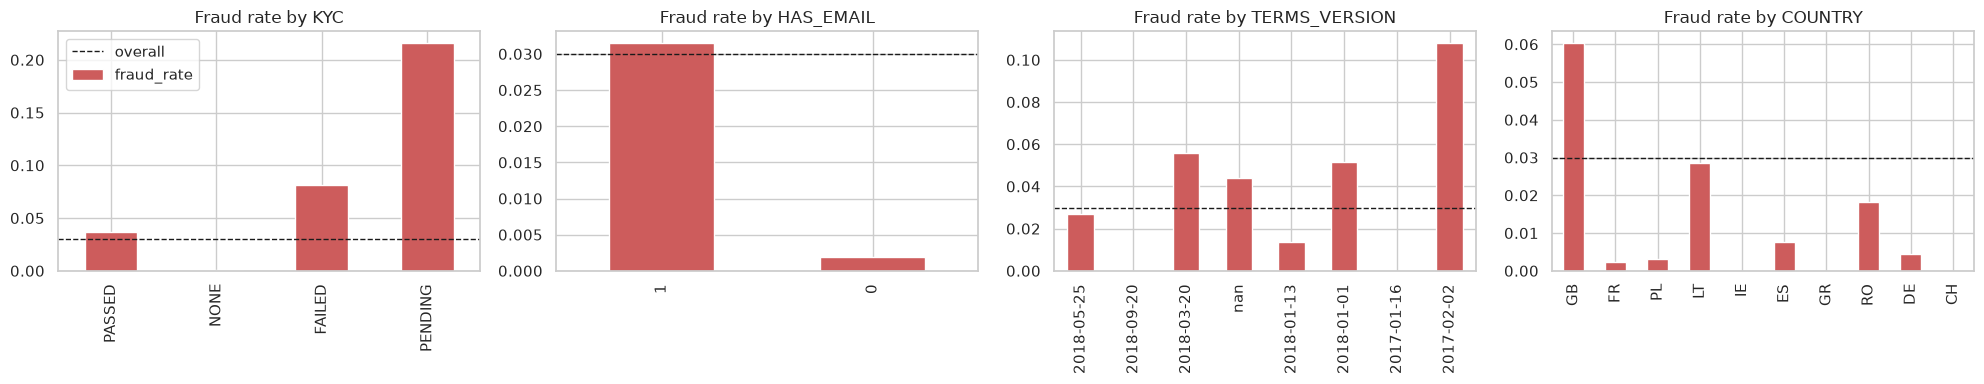

In [10]:
def fraud_rate_by(df, col, top=None):
    """Fraud rate and group size for each value of `col`, largest groups first."""
    out = (df.groupby(col, dropna=False)["IS_FRAUDSTER"]
             .agg(fraud_rate="mean", n_users="size")
             .sort_values("n_users", ascending=False))
    return out.head(top) if top else out

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (col, top) in zip(axes, [("KYC", None), ("HAS_EMAIL", None),
                                 ("TERMS_VERSION", None), ("COUNTRY", 10)]):
    rates = fraud_rate_by(users, col, top)
    rates["fraud_rate"].plot.bar(ax=ax, color="indianred")
    ax.axhline(users["IS_FRAUDSTER"].mean(), ls="--", c="k", lw=1, label="overall")
    ax.set_title(f"Fraud rate by {col}"); ax.set_xlabel("")
axes[0].legend()
plt.tight_layout()

In [11]:
fraud_rate_by(users, "KYC")

,fraud_rate,n_users
KYC,,
PASSED,0.037165,6969
NONE,0.000380,2631
FAILED,0.081481,270
PENDING,0.216216,74


,AGE,FAILED_SIGN_IN_ATTEMPTS
IS_FRAUDSTER,,
False,33.90,0.01
True,30.29,0.02


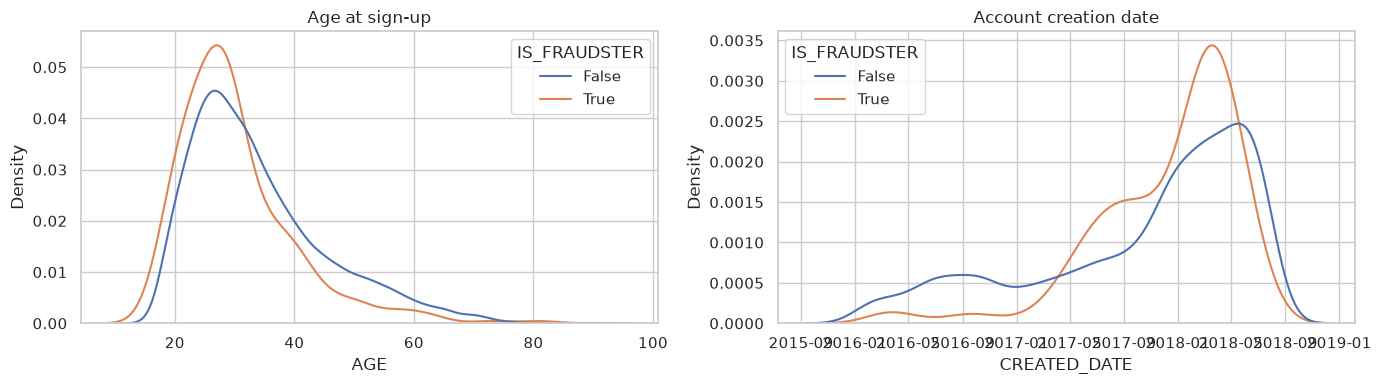

In [12]:
users["AGE"] = users["CREATED_DATE"].dt.year - users["BIRTH_YEAR"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(data=users, x="AGE", hue="IS_FRAUDSTER", common_norm=False, ax=axes[0])
axes[0].set_title("Age at sign-up")
sns.kdeplot(data=users, x="CREATED_DATE", hue="IS_FRAUDSTER", common_norm=False, ax=axes[1])
axes[1].set_title("Account creation date")
plt.tight_layout()

users.groupby("IS_FRAUDSTER")[["AGE", "FAILED_SIGN_IN_ATTEMPTS"]].mean().round(2)

**Observations — profile**
- **KYC** is very discriminant: `PENDING` (≈22%) and `FAILED` (≈8%) are far above the 3% baseline, while `NONE` is almost never fraud (those users mostly never transact).
- **Country**: fraud is concentrated in **GB (~6%)**; most other countries are close to 0%. Many small countries → we will keep the top ones and group the rest.
- **No email** → almost no fraud (same "inactive account" effect as KYC = NONE).
- Fraudsters are slightly **younger** (mean age at sign-up ≈30 vs 34) and their accounts are slightly **more recent**.
- `FAILED_SIGN_IN_ATTEMPTS` is almost always 0 → weak signal on its own.
- `TERMS_VERSION` differs between groups, but it mostly reflects *when* the account was created, so it is a proxy for sign-up date rather than behaviour.

### 2.2 Transactions

In [13]:
# Keep only labelled users and attach the target + user sign-up date
tx = (transactions[transactions["USER_ID"].isin(users["ID"])]
      .merge(users[["ID", "IS_FRAUDSTER", "CREATED_DATE"]]
             .rename(columns={"ID": "USER_ID", "CREATED_DATE": "USER_CREATED_DATE"}),
             on="USER_ID"))
print(tx.shape)
print("Fraud rate among users WITHOUT transactions:",
      f"{users.loc[~users['ID'].isin(tx['USER_ID']), 'IS_FRAUDSTER'].mean():.2%}")

(638742, 14)
Fraud rate among users WITHOUT transactions: 0.05%


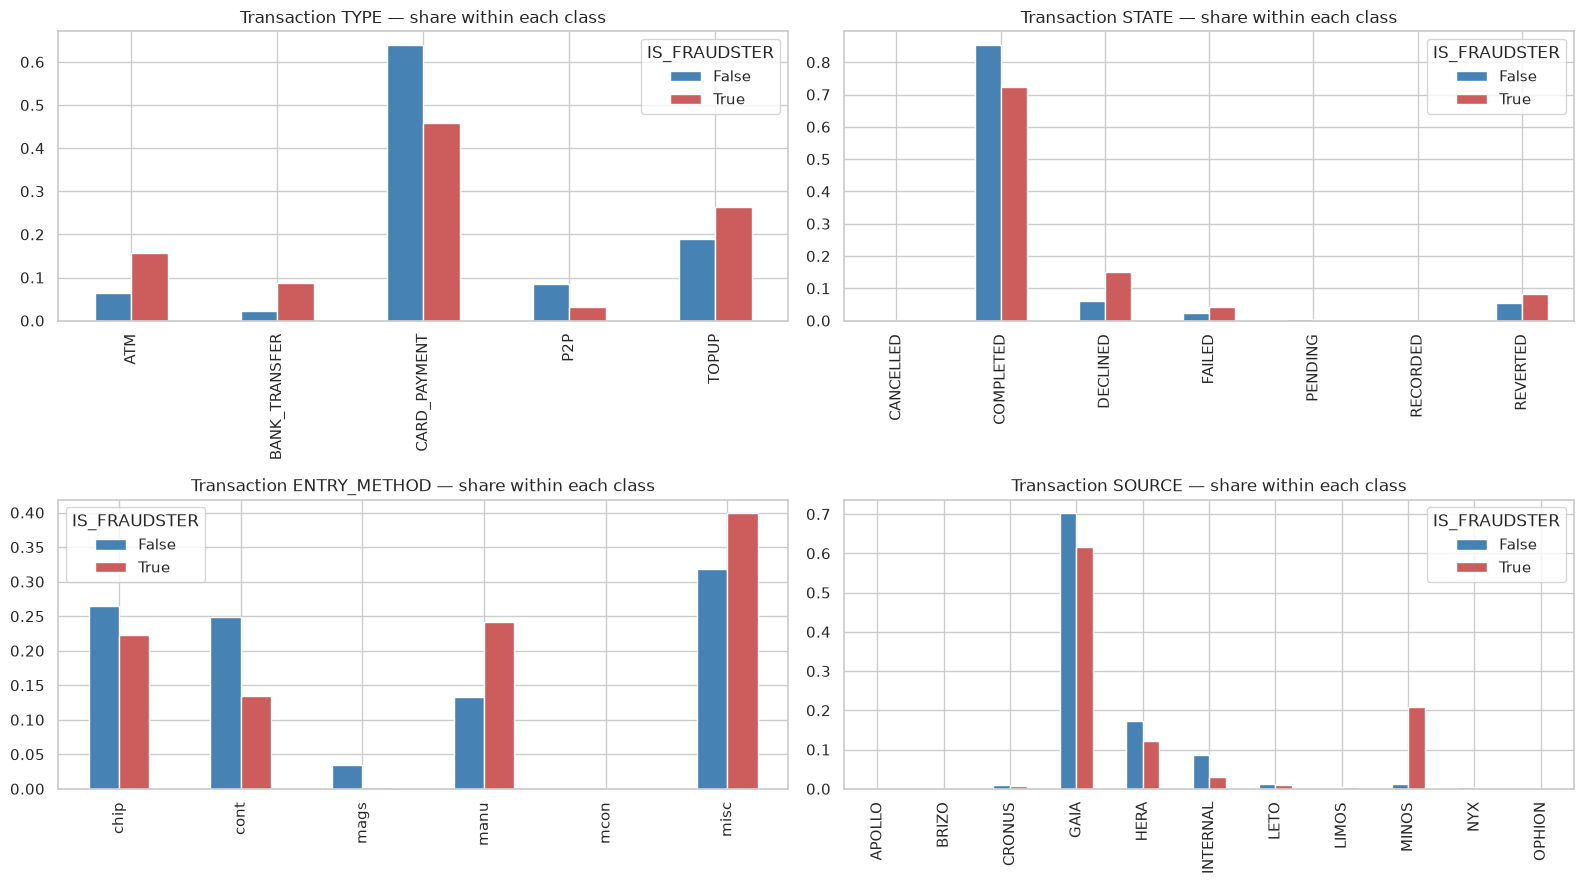

In [14]:
def mix_by_class(df, col):
    """Share of each category of `col` within fraud / non-fraud transactions."""
    return pd.crosstab(df[col], df["IS_FRAUDSTER"], normalize="columns").round(3)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, col in zip(axes.ravel(), ["TYPE", "STATE", "ENTRY_METHOD", "SOURCE"]):
    mix_by_class(tx, col).plot.bar(ax=ax, color=["steelblue", "indianred"])
    ax.set_title(f"Transaction {col} — share within each class"); ax.set_xlabel("")
plt.tight_layout()

In [15]:
mix_by_class(tx, "MERCHANT_CATEGORY").sort_values(True, ascending=False).head(8)

IS_FRAUDSTER,False,True
MERCHANT_CATEGORY,,
atm,0.042,0.238
point_of_interest,0.168,0.216
supermarket,0.139,0.094
bank,0.026,0.052
restaurant,0.110,0.052
convenience_store,0.031,0.051
bar,0.060,0.028
accounting,0.001,0.024


,count,mean,std,min,25%,50%,75%,max
IS_FRAUDSTER,,,,,,,,
False,572522.0,6489.0,73164.0,0.0,345.0,1000.0,3625.0,16412114.0
True,13603.0,22596.0,130237.0,0.0,376.0,1498.0,14885.0,5366546.0


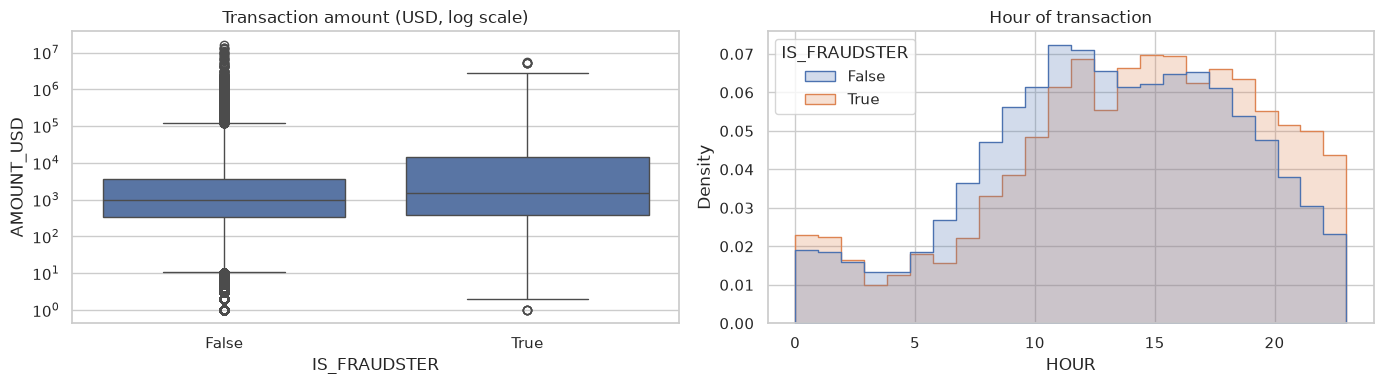

In [16]:
tx["HOUR"] = tx["CREATED_DATE"].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=tx, x="IS_FRAUDSTER", y="AMOUNT_USD", log_scale=True, ax=axes[0])
axes[0].set_title("Transaction amount (USD, log scale)")
sns.histplot(data=tx, x="HOUR", hue="IS_FRAUDSTER", stat="density",
             common_norm=False, bins=24, element="step", ax=axes[1])
axes[1].set_title("Hour of transaction")
plt.tight_layout()

tx.groupby("IS_FRAUDSTER")["AMOUNT_USD"].describe().round(0)

In [17]:
# Activity per user
per_user = tx.groupby("USER_ID").agg(
    is_fraudster=("IS_FRAUDSTER", "first"),
    n_tx=("ID", "size"),
    first_tx=("CREATED_DATE", "min"),
    last_tx=("CREATED_DATE", "max"),
    user_created=("USER_CREATED_DATE", "first"),
    n_currencies=("CURRENCY", "nunique"),
    declined_rate=("STATE", lambda s: (s == "DECLINED").mean()),
)
per_user["active_span_days"] = (per_user["last_tx"] - per_user["first_tx"]).dt.days
per_user["hours_to_first_tx"] = (per_user["first_tx"] - per_user["user_created"]).dt.total_seconds() / 3600

per_user.groupby("is_fraudster")[["n_tx", "active_span_days", "hours_to_first_tx",
                                  "n_currencies", "declined_rate"]].median().round(2)

,n_tx,active_span_days,hours_to_first_tx,n_currencies,declined_rate
is_fraudster,,,,,
False,26.0,99.0,0.31,1.0,0.02
True,22.0,38.0,0.87,1.0,0.08


**Observations — transactions**
- Users with no transaction are practically never fraudsters → "has transactions" is itself a strong signal.
- **Type**: fraudsters do far more **ATM withdrawals** (16% vs 6%), **bank transfers** (9% vs 2%) and **top-ups**, and fewer card payments / P2P → typical *cash-in, cash-out* pattern.
- **State**: fraudsters' transactions are **declined** much more often (15% vs 6%) and fail / are reverted more.
- **Entry method**: more **manual entry** (`manu`, 24% vs 13%) and less contactless / magnetic stripe → consistent with stolen card details typed in.
- **Source**: `MINOS` represents 21% of fraudsters' transactions vs 1% for others — strongest single categorical signal.
- **Merchant category**: `atm` dominates for fraudsters; fewer restaurants / bars / supermarkets (less "everyday life" spending).
- **Amounts**: fraudster transactions are larger (75th percentile ≈ 15k vs 3.6k USD).
- **Timing**: more evening activity (18h–23h) and less in the morning.
- **Activity**: fraudsters have fewer transactions and a much **shorter active span** (median 38 vs 99 days). ⚠️ Partly a consequence of being locked, so this must be interpreted carefully.

These observations drive the features built in Step 3.

## Step 3 — Feature engineering

The target is defined **per user**, so every transaction-level signal is aggregated to **one row per user**.
Each feature below comes from an observation of Step 2:

| Feature group | Features | Reasoning |
|---|---|---|
| Profile | `KYC_*`, `HAS_EMAIL`, `AGE`, `FAILED_SIGN_IN_ATTEMPTS` | KYC status is the strongest profile signal; fraudsters are younger. |
| Profile (creative) | `PHONE_MATCHES_COUNTRY` | A phone number from another country than the declared residence can indicate a fake / borrowed identity. |
| Country | `COUNTRY_GROUP_*` (top countries + `OTHER`) | Fraud is concentrated in GB; rare countries are grouped to avoid dozens of near-empty columns. |
| Activity | `HAS_TX`, `N_TX`, `LOG_AMOUNT_MEAN/MAX/SUM` | Users without transactions are almost never fraudsters; fraudsters move larger amounts. |
| Transaction mix | `TYPE_*`, `STATE_*`, `ENTRY_*`, `SOURCE_*`, `MERCHANT_ATM_SHARE` | Shares (not counts) so heavy and light users are comparable: ATM / transfers / declines / manual entry / MINOS are over-represented among fraudsters. |
| Timing | `EVENING_SHARE`, `NIGHT_SHARE`, `WEEKEND_SHARE`, `LOG_HOURS_TO_FIRST_TX` | Fraudsters are more active in the evening. Hypothesis: a fraudster uses the account right after opening it (in fact the median fraudster waits slightly *longer*: ~0.8h vs ~0.1h — most legitimate users top up within minutes of sign-up). |
| Geography / currency (creative) | `FOREIGN_MERCHANT_SHARE`, `N_CURRENCIES`, `N_MERCHANT_COUNTRIES` | Hypothesis: spending far from the home country / in many currencies is unusual for an ordinary customer (Step 6.4 shows the effect is actually the opposite). A crypto-currency share was tried but no user transacts in crypto, so it was dropped. |
| Cash-in / cash-out (creative) | `CASH_OUT_SHARE` | Money mules top up the account then withdraw / transfer it out: (ATM + transfers) / (top-ups + ATM + transfers), bounded in [0, 1]. |

**Deliberately excluded**
- `STATE` (user) — target leak (LOCKED ⇔ fraudster).
- Last-transaction date, active span — they are shaped by the account being locked *after* detection, so they describe the consequence of the label rather than the behaviour.
- `CREATED_DATE`, `TERMS_VERSION` — mostly encode *when* the user signed up; they would not generalise to future users.
- `ID` / `USER_ID` — identifiers.

In [18]:
# Lookups from the dictionary files
COUNTRY_ISO3 = countries.set_index("CODE")["CODE3"]

# Category levels kept, chosen from the Step 2 analysis
TOP_COUNTRIES = ["GB", "FR", "PL", "LT", "IE", "ES", "RO"]
SHARE_LEVELS = {
    "TYPE": ["ATM", "BANK_TRANSFER", "CARD_PAYMENT", "P2P", "TOPUP"],
    "STATE": ["DECLINED", "FAILED", "REVERTED"],
    "ENTRY_METHOD": ["manu", "chip", "cont", "mags", "misc"],
    "SOURCE": ["MINOS", "INTERNAL", "GAIA", "HERA"],
}
EVENING_HOURS = range(18, 24)
NIGHT_HOURS = range(0, 6)
CASH_OUT_TYPES = ["ATM", "BANK_TRANSFER"]

In [19]:
def profile_features(users):
    """One row per user built from users.csv (STATE excluded: target leak)."""
    phone_match = [country in str(phones).split("||")
                   for country, phones in zip(users["COUNTRY"], users["PHONE_COUNTRY"])]
    df = pd.DataFrame({
        "USER_ID": users["ID"],
        "HAS_EMAIL": users["HAS_EMAIL"],
        "FAILED_SIGN_IN_ATTEMPTS": users["FAILED_SIGN_IN_ATTEMPTS"],
        "AGE": users["CREATED_DATE"].dt.year - users["BIRTH_YEAR"],
        "PHONE_MATCHES_COUNTRY": np.array(phone_match, dtype=int),
        "KYC": users["KYC"],
        "COUNTRY_GROUP": users["COUNTRY"].where(users["COUNTRY"].isin(TOP_COUNTRIES), "OTHER"),
    })
    return pd.get_dummies(df, columns=["KYC", "COUNTRY_GROUP"], dtype=int).set_index("USER_ID")


def share_features(tx):
    """Share of each selected category per user (TYPE, STATE, ENTRY_METHOD, SOURCE, ATM merchant)."""
    parts = [
        pd.crosstab(tx["USER_ID"], tx[col], normalize="index")
          .reindex(columns=levels, fill_value=0)
          .add_prefix(f"{col}_")
        for col, levels in SHARE_LEVELS.items()
    ]
    atm_share = (tx["MERCHANT_CATEGORY"] == "atm").groupby(tx["USER_ID"]).mean()
    return pd.concat(parts, axis=1).assign(MERCHANT_ATM_SHARE=atm_share)


def activity_features(tx, users):
    """Volume, amount, timing, geography and cash-in/cash-out aggregates per user."""
    user_info = users.set_index("ID")
    home_iso3 = tx["USER_ID"].map(user_info["COUNTRY"]).map(COUNTRY_ISO3)
    hour = tx["CREATED_DATE"].dt.hour
    enriched = tx.assign(
        IS_EVENING=hour.isin(EVENING_HOURS),
        IS_NIGHT=hour.isin(NIGHT_HOURS),
        IS_WEEKEND=tx["CREATED_DATE"].dt.dayofweek >= 5,
        IS_FOREIGN=tx["MERCHANT_COUNTRY"].notna() & (tx["MERCHANT_COUNTRY"] != home_iso3),
        CASH_IN_USD=tx["AMOUNT_USD"].where(tx["TYPE"] == "TOPUP", 0),
        CASH_OUT_USD=tx["AMOUNT_USD"].where(tx["TYPE"].isin(CASH_OUT_TYPES), 0),
    )
    agg = enriched.groupby("USER_ID").agg(
        N_TX=("ID", "size"),
        AMOUNT_MEAN=("AMOUNT_USD", "mean"),
        AMOUNT_MAX=("AMOUNT_USD", "max"),
        AMOUNT_SUM=("AMOUNT_USD", "sum"),
        N_CURRENCIES=("CURRENCY", "nunique"),
        N_MERCHANT_COUNTRIES=("MERCHANT_COUNTRY", "nunique"),
        EVENING_SHARE=("IS_EVENING", "mean"),
        NIGHT_SHARE=("IS_NIGHT", "mean"),
        WEEKEND_SHARE=("IS_WEEKEND", "mean"),
        FOREIGN_MERCHANT_SHARE=("IS_FOREIGN", "mean"),
        CASH_IN=("CASH_IN_USD", "sum"),
        CASH_OUT=("CASH_OUT_USD", "sum"),
        FIRST_TX=("CREATED_DATE", "min"),
    )
    hours_to_first = (agg["FIRST_TX"] - agg.index.map(user_info["CREATED_DATE"])).dt.total_seconds() / 3600
    return (agg
            .assign(LOG_AMOUNT_MEAN=np.log1p(agg["AMOUNT_MEAN"].fillna(0)),
                    LOG_AMOUNT_MAX=np.log1p(agg["AMOUNT_MAX"].fillna(0)),
                    LOG_AMOUNT_SUM=np.log1p(agg["AMOUNT_SUM"]),
                    LOG_HOURS_TO_FIRST_TX=np.log1p(hours_to_first.clip(lower=0)),
                    CASH_OUT_SHARE=(agg["CASH_OUT"] / (agg["CASH_IN"] + agg["CASH_OUT"])).fillna(0))
            .drop(columns=["AMOUNT_MEAN", "AMOUNT_MAX", "AMOUNT_SUM", "CASH_IN", "CASH_OUT", "FIRST_TX"]))

In [20]:
def build_feature_table(users, tx):
    """Final modelling table: one row per user, features + target.

    Users without any transaction get 0 for transaction features;
    HAS_TX lets the model tell "no activity" apart from "zero values"."""
    tx_feats = activity_features(tx, users).join(share_features(tx))
    features = (profile_features(users)
                .join(tx_feats)
                .assign(HAS_TX=lambda d: d["N_TX"].notna().astype(int))
                .fillna(0))
    target = users.set_index("ID")["IS_FRAUDSTER"].astype(int).rename("IS_FRAUDSTER")
    return features.join(target)


data = build_feature_table(users, tx)
FEATURES = [c for c in data.columns if c != "IS_FRAUDSTER"]
print(data.shape, "|", len(FEATURES), "features | missing values:", data.isna().sum().sum())
data.head()

(9944, 48) | 47 features | missing values: 0


,HAS_EMAIL,FAILED_SIGN_IN_ATTEMPTS,AGE,PHONE_MATCHES_COUNTRY,KYC_FAILED,KYC_NONE,KYC_PASSED,KYC_PENDING,COUNTRY_GROUP_ES,COUNTRY_GROUP_FR,COUNTRY_GROUP_GB,COUNTRY_GROUP_IE,COUNTRY_GROUP_LT,COUNTRY_GROUP_OTHER,COUNTRY_GROUP_PL,COUNTRY_GROUP_RO,N_TX,N_CURRENCIES,N_MERCHANT_COUNTRIES,EVENING_SHARE,NIGHT_SHARE,WEEKEND_SHARE,FOREIGN_MERCHANT_SHARE,LOG_AMOUNT_MEAN,LOG_AMOUNT_MAX,LOG_AMOUNT_SUM,LOG_HOURS_TO_FIRST_TX,CASH_OUT_SHARE,TYPE_ATM,TYPE_BANK_TRANSFER,TYPE_CARD_PAYMENT,TYPE_P2P,TYPE_TOPUP,STATE_DECLINED,STATE_FAILED,STATE_REVERTED,ENTRY_METHOD_manu,ENTRY_METHOD_chip,ENTRY_METHOD_cont,ENTRY_METHOD_mags,ENTRY_METHOD_misc,SOURCE_MINOS,SOURCE_INTERNAL,SOURCE_GAIA,SOURCE_HERA,MERCHANT_ATM_SHARE,HAS_TX,IS_FRAUDSTER
USER_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1872820f-e3ac-4c02-bdc7-727897b60043,1,0,46,1,0,0,1,0,0,0,1,0,0,0,0,0,6.0,2.0,1.0,0.000000,0.000000,0.666667,0.500000,9.241225,10.522207,11.032904,5.008853,0.356292,0.166667,0.000000,0.333333,0.000000,0.500000,0.000000,0.000000,0.166667,0.000000,0.333333,0.166667,0.000000,0.500000,0.000000,0.000000,0.500000,0.500000,0.0,1,0
545ff94d-66f8-4bea-b398-84425fb2301e,1,0,35,1,0,0,1,0,0,0,1,0,0,0,0,0,11.0,1.0,2.0,0.181818,0.000000,0.181818,0.454545,8.292526,10.295800,10.690193,0.031081,0.000000,0.000000,0.000000,0.454545,0.181818,0.363636,0.000000,0.090909,0.090909,0.000000,0.181818,0.272727,0.000000,0.545455,0.000000,0.181818,0.454545,0.363636,0.0,1,0
10376f1a-a28a-4885-8daa-c8ca496026bb,1,0,45,1,0,0,1,0,1,0,0,0,0,0,0,0,60.0,1.0,8.0,0.266667,0.016667,0.166667,0.500000,7.553007,10.444532,11.646836,5.556823,0.000000,0.000000,0.000000,0.500000,0.383333,0.116667,0.100000,0.033333,0.116667,0.300000,0.150000,0.033333,0.016667,0.500000,0.000000,0.383333,0.500000,0.116667,0.0,1,0
fd308db7-0753-4377-879f-6ecf2af14e4f,1,0,32,1,0,0,1,0,0,1,0,0,0,0,0,0,2.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,6.523562,7.151485,7.215975,4.285895,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,1,0
755fe256-a34d-4853-b7ca-d9bb991a86d3,1,0,28,1,0,0,1,0,0,0,1,0,0,0,0,0,121.0,2.0,3.0,0.355372,0.272727,0.247934,0.727273,11.793678,15.319032,16.589462,0.349874,0.342872,0.000000,0.057851,0.727273,0.049587,0.165289,0.066116,0.016529,0.074380,0.256198,0.181818,0.198347,0.090909,0.272727,0.049587,0.049587,0.727273,0.140496,0.0,1,0


### Sanity check — signal of each feature on its own

Single-feature ROC-AUC (0.5 = no signal; values far from 0.5 in either direction are informative).
This is only a descriptive check — features are **not** selected on it, so it does not bias the evaluation.

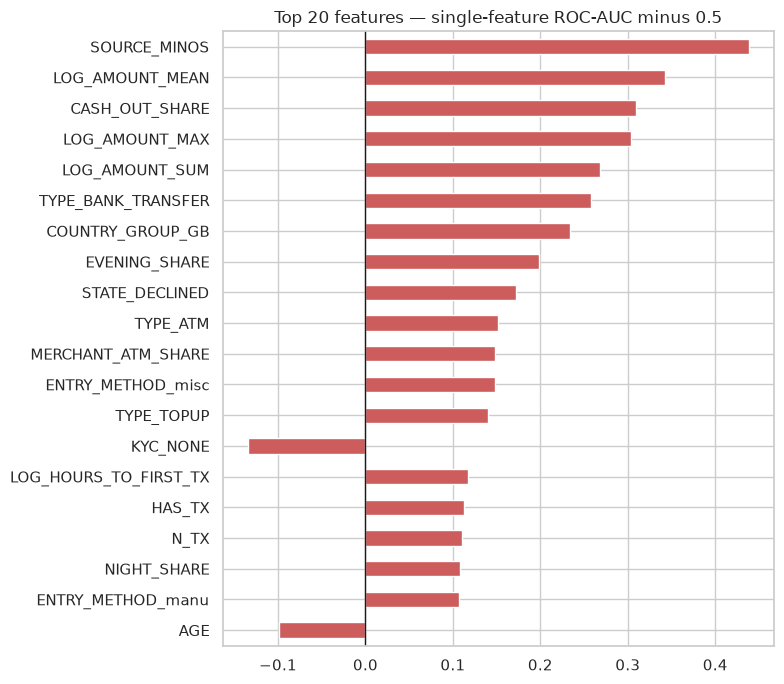

In [21]:
from sklearn.metrics import roc_auc_score

single_auc = pd.Series({f: roc_auc_score(data["IS_FRAUDSTER"], data[f]) for f in FEATURES})
signal = (single_auc - 0.5).abs().sort_values(ascending=False)

ax = (single_auc[signal.index[:20]] - 0.5).plot.barh(figsize=(8, 7), color="indianred")
ax.invert_yaxis(); ax.axvline(0, c="k", lw=1)
ax.set_title("Top 20 features — single-feature ROC-AUC minus 0.5")
plt.tight_layout()

**Observations — feature signal**
- `SOURCE_MINOS` is by far the strongest single feature (AUC ≈ 0.94): 92% of fraudsters have at least one MINOS transaction (bank transfers / top-ups) vs 16% of other users.
  It was checked for leakage: MINOS transactions are spread over the whole life of the account (not concentrated after the lock), so it looks like a genuine channel signal. Still, a model relying on one channel is fragile → Step 5 also evaluates a model **without** it.
- Amount features, `CASH_OUT_SHARE`, bank-transfer share and GB residence come next — consistent with the cash-in / cash-out pattern seen in Step 2.
- Some features are weak alone (`PHONE_MATCHES_COUNTRY`, `WEEKEND_SHARE`, `N_CURRENCIES`); they are kept because they may help in combination, and the model's feature importance will tell.

## Step 4 — Modelling

**Split strategy** — stratified **60% train / 20% validation / 20% test** (same 3% fraud rate in each part):
- *train*: fit the models (+ 5-fold cross-validation to compare them robustly — only ~180 fraudsters in train, so a single split would be noisy);
- *validation*: compare fitted models and later choose the decision threshold;
- *test*: touched **once**, at the very end, for the final unbiased estimate.

**Metric** — **PR-AUC (average precision)** is the main metric: with 3% positives, ROC-AUC and accuracy look good even for weak models, while PR-AUC directly reflects how precise the alerts are at each recall level. ROC-AUC is reported as a secondary metric.

**Models compared**
1. **Logistic Regression** (`class_weight="balanced"`, standardised features) — simple, interpretable baseline.
2. **Random Forest** (`class_weight="balanced_subsample"`) — captures non-linear effects and interactions, robust to un-scaled / skewed features.
3. **Histogram Gradient Boosting** (`class_weight="balanced"`) — usually the strongest family on tabular data.

In [22]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve

X, y = data[FEATURES], data["IS_FRAUDSTER"]
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=RANDOM_STATE)

pd.DataFrame({"n_users": [len(y_train), len(y_val), len(y_test)],
              "n_fraudsters": [y_train.sum(), y_val.sum(), y_test.sum()],
              "fraud_rate": [y_train.mean(), y_val.mean(), y_test.mean()]},
             index=["train", "validation", "test"]).round(3)

,n_users,n_fraudsters,fraud_rate
train,5966,179,0.03
validation,1989,60,0.03
test,1989,59,0.03


In [23]:
def make_models():
    return {
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
        "Random Forest": RandomForestClassifier(
            n_estimators=500, min_samples_leaf=3, class_weight="balanced_subsample",
            n_jobs=-1, random_state=RANDOM_STATE),
        "Gradient Boosting": HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=300, max_leaf_nodes=15, l2_regularization=1.0,
            class_weight="balanced", random_state=RANDOM_STATE),
    }


def cross_validate_models(models, X, y, n_splits=5):
    """Mean ± std of PR-AUC and ROC-AUC over stratified K folds."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = {}
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=["average_precision", "roc_auc"], n_jobs=-1)
        rows[name] = {"cv_pr_auc": scores["test_average_precision"].mean(),
                      "cv_pr_auc_std": scores["test_average_precision"].std(),
                      "cv_roc_auc": scores["test_roc_auc"].mean()}
    return pd.DataFrame(rows).T.round(3)


cv_results = cross_validate_models(make_models(), X_train, y_train)
cv_results

,cv_pr_auc,cv_pr_auc_std,cv_roc_auc
Logistic Regression,0.743,0.104,0.972
Random Forest,0.800,0.056,0.976
Gradient Boosting,0.807,0.059,0.981


,cv_pr_auc,cv_pr_auc_std,cv_roc_auc,val_pr_auc,val_roc_auc
Logistic Regression,0.743,0.104,0.972,0.795,0.974
Random Forest,0.800,0.056,0.976,0.838,0.973
Gradient Boosting,0.807,0.059,0.981,0.878,0.976


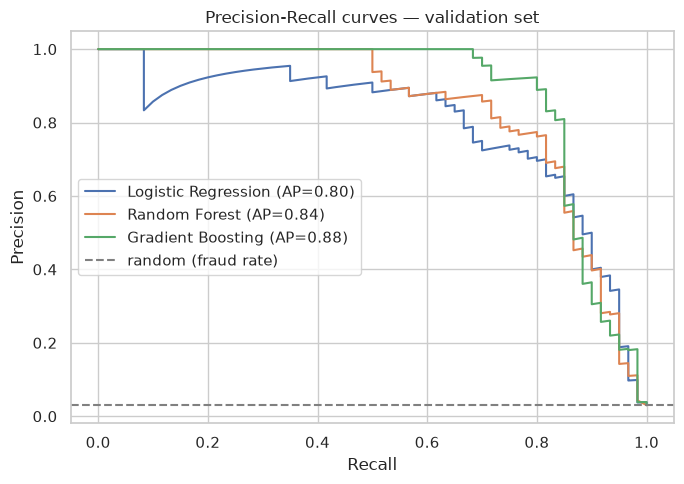

In [24]:
# Fit on the full training set, score on the validation set
models = {name: model.fit(X_train, y_train) for name, model in make_models().items()}
val_proba = {name: model.predict_proba(X_val)[:, 1] for name, model in models.items()}

val_results = pd.DataFrame({
    name: {"val_pr_auc": average_precision_score(y_val, p), "val_roc_auc": roc_auc_score(y_val, p)}
    for name, p in val_proba.items()}).T.round(3)
display(cv_results.join(val_results))

fig, ax = plt.subplots(figsize=(7, 5))
for name, p in val_proba.items():
    precision, recall, _ = precision_recall_curve(y_val, p)
    ax.plot(recall, precision, label=f"{name} (AP={average_precision_score(y_val, p):.2f})")
ax.axhline(y_val.mean(), ls="--", c="grey", label="random (fraud rate)")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision-Recall curves — validation set")
ax.legend(); plt.tight_layout()

**Observations — model comparison**
- All three models are far above the random baseline (PR-AUC = 0.03): the engineered features carry a lot of signal.
- ROC-AUC is ≈0.97–0.98 for every model and **does not discriminate** between them — this is why PR-AUC is the main metric.
- The tree-based models beat the logistic regression on PR-AUC (≈0.80 vs 0.74 in CV) and are **more stable across folds** (std ≈0.06 vs 0.10): they capture non-linear effects (e.g. the KYC × activity interaction, thresholds on amounts) that a linear model cannot.
- **Gradient Boosting** is the best on both cross-validation (0.81) and validation (0.88), so it is selected.
- Validation scores are a bit higher than CV scores: with only 60 fraudsters in validation, a few users more or less correctly ranked move PR-AUC by several points — the CV std (±0.06) is a more honest idea of the uncertainty.
- Hyper-parameters were set to reasonable defaults (small trees, low learning rate, L2 regularisation) rather than heavily tuned: with ~180 training fraudsters, aggressive tuning would mostly overfit the folds.

In [25]:
BEST_MODEL_NAME = cv_results["cv_pr_auc"].idxmax()
best_model = models[BEST_MODEL_NAME]
print("Selected model:", BEST_MODEL_NAME)

Selected model: Gradient Boosting


## Step 5 — Evaluation

### 5.1 Choosing the decision threshold (validation set)

The model outputs a probability; flagging a user requires a threshold. The default 0.5 is arbitrary, especially with class weights.
In fraud detection **missing a fraudster costs more than reviewing an honest user** (money lost vs a few minutes of an analyst's time), so recall matters more than precision.
The threshold is chosen on the **validation set** by maximising the **F2-score** (recall weighted twice as much as precision).

Chosen threshold: 0.466 -> validation precision 0.81, recall 0.85, F2 0.84


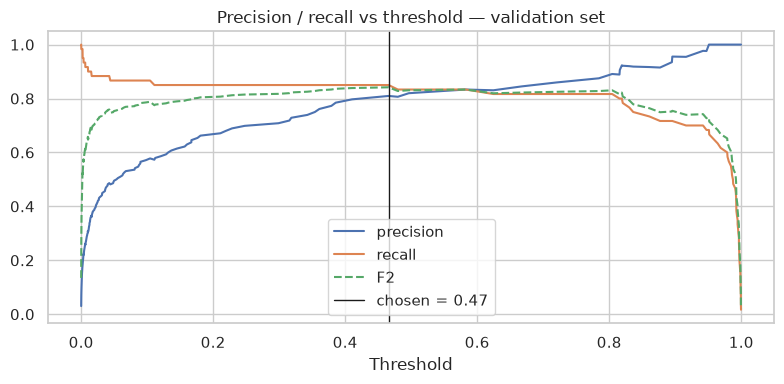

In [26]:
from sklearn.metrics import fbeta_score

BETA = 2
val_scores = best_model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_scores)
f2 = (1 + BETA**2) * precision * recall / (BETA**2 * precision + recall + 1e-12)
best_idx = np.argmax(f2[:-1])           # last point has no threshold
THRESHOLD = thresholds[best_idx]
print(f"Chosen threshold: {THRESHOLD:.3f} -> validation precision {precision[best_idx]:.2f}, "
      f"recall {recall[best_idx]:.2f}, F2 {f2[best_idx]:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precision[:-1], label="precision")
ax.plot(thresholds, recall[:-1], label="recall")
ax.plot(thresholds, f2[:-1], label="F2", ls="--")
ax.axvline(THRESHOLD, c="k", lw=1, label=f"chosen = {THRESHOLD:.2f}")
ax.set_xlabel("Threshold"); ax.set_title("Precision / recall vs threshold — validation set")
ax.legend(); plt.tight_layout()

**Observation** — the F2-optimal threshold (≈0.47) ends up very close to 0.5: thanks to `class_weight="balanced"` the probabilities are already shifted towards the minority class. On validation it gives precision ≈0.81 and recall ≈0.85.
In production this threshold would rather be set from the **real costs** (average fraud loss vs cost of a manual review) or from the **analysts' review capacity** — see the top-k view in 5.4.

### 5.2 What drives the model? (permutation importance, validation set)

Gradient boosting has no coefficients, so importance is measured by **permutation**: shuffle one feature and measure how much validation PR-AUC drops.

,mean_drop,std
SOURCE_MINOS,0.529,0.035
N_CURRENCIES,0.057,0.012
LOG_AMOUNT_SUM,0.049,0.016
ENTRY_METHOD_manu,0.028,0.006
N_MERCHANT_COUNTRIES,0.027,0.009
STATE_DECLINED,0.026,0.008
ENTRY_METHOD_mags,0.025,0.006
SOURCE_HERA,0.014,0.006
LOG_HOURS_TO_FIRST_TX,0.009,0.006
STATE_FAILED,0.009,0.004


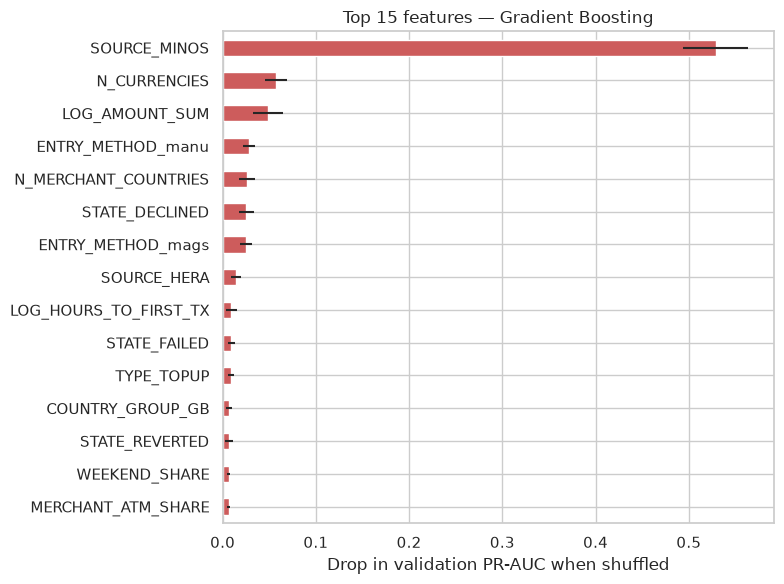

In [27]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_model, X_val, y_val, scoring="average_precision",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.DataFrame({"mean_drop": perm.importances_mean, "std": perm.importances_std}, index=FEATURES)
                .sort_values("mean_drop", ascending=False))

ax = importance["mean_drop"].head(15).plot.barh(xerr=importance["std"].head(15), figsize=(8, 6), color="indianred")
ax.invert_yaxis(); ax.set_xlabel("Drop in validation PR-AUC when shuffled")
ax.set_title(f"Top 15 features — {BEST_MODEL_NAME}")
plt.tight_layout()
importance.head(10).round(3)

**Observation**
- `SOURCE_MINOS` dominates: shuffling it destroys ≈0.53 of PR-AUC. The model has learned that "uses the MINOS channel" is the main fraud marker.
- Next come diversity / volume features (`N_CURRENCIES`, `N_MERCHANT_COUNTRIES`, `LOG_AMOUNT_SUM`) and the "suspicious usage" features found in the EDA: **manual card entry**, **declined / failed transactions**.
- `ENTRY_METHOD_mags` matters too, in the opposite direction: magnetic-stripe use (physical card, older habit) is typical of legitimate users.
- Many profile features (KYC, country) have little *additional* importance once behaviour is known: their information is largely captured by the transaction features.

### 5.3 Robustness: how dependent is the model on `SOURCE_MINOS`?

`SOURCE_MINOS` was by far the strongest single feature. If this channel changed (or if MINOS is itself linked to how fraud cases are currently detected), a model relying on it would break.
The same model is retrained **without** it and compared on cross-validation and validation.

In [28]:
FEATURES_NO_MINOS = [f for f in FEATURES if f != "SOURCE_MINOS"]
gb_no_minos = {"Gradient Boosting (no MINOS)": make_models()["Gradient Boosting"]}

cv_no_minos = cross_validate_models(gb_no_minos, X_train[FEATURES_NO_MINOS], y_train)
model_no_minos = gb_no_minos["Gradient Boosting (no MINOS)"].fit(X_train[FEATURES_NO_MINOS], y_train)
p_no_minos = model_no_minos.predict_proba(X_val[FEATURES_NO_MINOS])[:, 1]
cv_no_minos["val_pr_auc"] = average_precision_score(y_val, p_no_minos)

pd.concat([cv_results.loc[[BEST_MODEL_NAME], ["cv_pr_auc", "cv_pr_auc_std"]]
             .assign(val_pr_auc=val_results.loc[BEST_MODEL_NAME, "val_pr_auc"]),
           cv_no_minos[["cv_pr_auc", "cv_pr_auc_std", "val_pr_auc"]]]).round(3)

,cv_pr_auc,cv_pr_auc_std,val_pr_auc
Gradient Boosting,0.807,0.059,0.878
Gradient Boosting (no MINOS),0.776,0.066,0.809


**Observation** — without `SOURCE_MINOS`, PR-AUC only drops from 0.81 to 0.78 in cross-validation (within one standard deviation) and from 0.88 to 0.81 on validation.
So although the full model *leans* on MINOS, the other behavioural features carry most of the same information and the model **degrades gracefully**. This is reassuring: if the MINOS channel changed, a retrained model would still work. In production, the no-MINOS version would be a sensible fallback / challenger model.

### 5.4 Final evaluation on the test set (used once)

Test PR-AUC : 0.826  (random = 0.030)
Test ROC-AUC: 0.989

              precision    recall  f1-score   support

       legit      0.993     0.993     0.993      1930
   fraudster      0.763     0.763     0.763        59

    accuracy                          0.986      1989
   macro avg      0.878     0.878     0.878      1989
weighted avg      0.986     0.986     0.986      1989



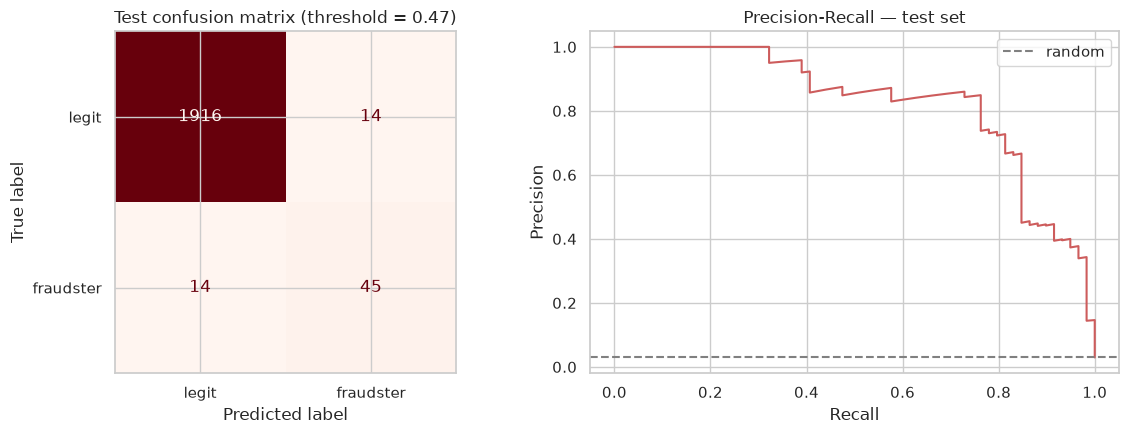

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score

test_scores = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_scores >= THRESHOLD).astype(int)

print(f"Test PR-AUC : {average_precision_score(y_test, test_scores):.3f}  (random = {y_test.mean():.3f})")
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_scores):.3f}\n")
print(classification_report(y_test, test_pred, target_names=["legit", "fraudster"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=["legit", "fraudster"]).plot(
    ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title(f"Test confusion matrix (threshold = {THRESHOLD:.2f})")
p_t, r_t, _ = precision_recall_curve(y_test, test_scores)
axes[1].plot(r_t, p_t, c="indianred")
axes[1].axhline(y_test.mean(), ls="--", c="grey", label="random")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall — test set")
axes[1].legend(); plt.tight_layout()

In [30]:
# Compare with the naive 0.5 threshold, and with "flag the top-k riskiest users" (analyst capacity view)
def alert_stats(y_true, flagged):
    return {"n_flagged": int(flagged.sum()), "fraud_caught": int((flagged & (y_true == 1)).sum()),
            "precision": precision_score(y_true, flagged, zero_division=0), "recall": recall_score(y_true, flagged)}

rank = pd.Series(test_scores, index=y_test.index).rank(ascending=False)
pd.DataFrame({
    "threshold 0.50": alert_stats(y_test, test_scores >= 0.5),
    f"threshold {THRESHOLD:.2f} (F2)": alert_stats(y_test, test_scores >= THRESHOLD),
    "top 2% riskiest": alert_stats(y_test, (rank <= 0.02 * len(y_test)).values),
    "top 5% riskiest": alert_stats(y_test, (rank <= 0.05 * len(y_test)).values),
}).T.round(3)

,n_flagged,fraud_caught,precision,recall
threshold 0.50,59.0,45.0,0.763,0.763
threshold 0.47 (F2),59.0,45.0,0.763,0.763
top 2% riskiest,39.0,34.0,0.872,0.576
top 5% riskiest,99.0,50.0,0.505,0.847


In [31]:
# Error analysis: what do the missed fraudsters look like?
test_view = X_test.assign(IS_FRAUDSTER=y_test, score=test_scores, flagged=test_pred)
fraud_view = test_view[test_view["IS_FRAUDSTER"] == 1].assign(
    outcome=lambda d: np.where(d["flagged"] == 1, "caught", "missed"))
cols = ["score", "HAS_TX", "N_TX", "SOURCE_MINOS", "LOG_AMOUNT_MEAN", "CASH_OUT_SHARE", "COUNTRY_GROUP_GB", "KYC_PASSED"]
fraud_view.groupby("outcome")[cols].agg(["median"]).droplevel(1, axis=1).assign(
    n=fraud_view["outcome"].value_counts()).round(2)

,score,HAS_TX,N_TX,SOURCE_MINOS,LOG_AMOUNT_MEAN,CASH_OUT_SHARE,COUNTRY_GROUP_GB,KYC_PASSED,n
outcome,,,,,,,,,
caught,0.99,1.0,24.0,0.33,9.86,0.49,1.0,1.0,45
missed,0.03,1.0,23.5,0.12,8.26,0.40,1.0,1.0,14


**Observations — test set**
- **PR-AUC 0.83** on the test set (vs 0.03 for random ranking), consistent with the cross-validation estimate (0.81 ± 0.06) → no sign of overfitting to the validation set.
- At the chosen threshold: **45 of the 59 fraudsters are caught (recall 0.76)** and **76% of alerts are real fraudsters** (14 false alarms out of 1,930 legitimate users, i.e. 0.7% of honest users bothered).
- Recall is lower than on validation (0.85): with ~60 fraudsters per set, one fraudster = 1.7 points of recall, so this gap is within the expected noise.
- Accuracy is 98.6%, but a model predicting "nobody is a fraudster" would already score 97% — this is why accuracy is not used.
- **Ranking view (more realistic for an investigation team):** reviewing the riskiest **2%** of users finds 34 fraudsters with **87% precision**; reviewing **5%** finds 50 of 59 (**85% recall**) at 50% precision. The threshold is a business choice along this curve.
- **Missed fraudsters** are not borderline cases: their median score is 0.03. They look like normal customers — fewer MINOS transactions, smaller amounts, less cash-out. These are probably frauds of a different kind (e.g. account takeover of a normal-looking account), which behavioural aggregates over the whole history struggle to see.

## Step 6 — Improvements

The limitations listed after Step 5 are addressed one by one. Decisions are still made on **cross-validation / validation only**; the test set is only used to report the final model.

### 6.1 Sequence features — *how* money moves, not only how much

The Step 2 aggregates ignore the **order** of transactions. Fraud patterns are often sequential:

| Feature | Reasoning |
|---|---|
| `FAST_CASH_OUT_SHARE` | Share of cash-outs (ATM / transfer) made **within 24h of a top-up** — money mules pass money through quickly. |
| `MAX_TX_PER_HOUR`, `MAX_TX_PER_DAY` | **Velocity**: bursts of activity (card testing, draining an account). |
| `MAX_DECLINED_STREAK` | Longest run of consecutive declined / failed transactions — repeated attempts with bad card details. |
| `LOG_MEDIAN_GAP_H` | Typical time between two transactions (regular customer vs short intense usage). |

In [32]:
FAST_CASH_OUT_HOURS = 24
BAD_STATES = ["DECLINED", "FAILED"]


def sequence_features(tx):
    """Order-aware features per user: velocity, declined streaks, top-up -> cash-out speed."""
    tx = tx.sort_values(["USER_ID", "CREATED_DATE"])
    by_user = tx.groupby("USER_ID")

    max_per_hour = tx.groupby(["USER_ID", tx["CREATED_DATE"].dt.floor("h")]).size().groupby(level=0).max()
    max_per_day = tx.groupby(["USER_ID", tx["CREATED_DATE"].dt.floor("D")]).size().groupby(level=0).max()
    gap_hours = by_user["CREATED_DATE"].diff().dt.total_seconds() / 3600
    median_gap = gap_hours.groupby(tx["USER_ID"]).median()

    # Longest run of consecutive declined / failed transactions
    is_bad = tx["STATE"].isin(BAD_STATES)
    run_id = (is_bad != is_bad.groupby(tx["USER_ID"]).shift()).cumsum()
    max_bad_streak = is_bad.groupby(run_id).transform("sum").groupby(tx["USER_ID"]).max()

    # For every cash-out, time since the user's previous top-up
    topups = (tx.loc[tx["TYPE"] == "TOPUP", ["USER_ID", "CREATED_DATE"]]
                .rename(columns={"CREATED_DATE": "TOPUP_DATE"}).sort_values("TOPUP_DATE"))
    cash_outs = tx.loc[tx["TYPE"].isin(CASH_OUT_TYPES), ["USER_ID", "CREATED_DATE"]].sort_values("CREATED_DATE")
    linked = pd.merge_asof(cash_outs, topups, left_on="CREATED_DATE", right_on="TOPUP_DATE",
                           by="USER_ID", direction="backward")
    delay_hours = (linked["CREATED_DATE"] - linked["TOPUP_DATE"]).dt.total_seconds() / 3600
    fast_share = (delay_hours <= FAST_CASH_OUT_HOURS).groupby(linked["USER_ID"]).mean()

    return pd.DataFrame({
        "FAST_CASH_OUT_SHARE": fast_share,
        "MAX_TX_PER_HOUR": max_per_hour,
        "MAX_TX_PER_DAY": max_per_day,
        "MAX_DECLINED_STREAK": max_bad_streak,
        "LOG_MEDIAN_GAP_H": np.log1p(median_gap),
    })


seq = sequence_features(tx)
SEQ_FEATURES = list(seq.columns)
data_v2 = data.join(seq).fillna(0)
FEATURES_V2 = FEATURES + SEQ_FEATURES

display(pd.Series({f: roc_auc_score(data_v2["IS_FRAUDSTER"], data_v2[f]) for f in SEQ_FEATURES},
                  name="single_feature_roc_auc").round(3))
data_v2.groupby("IS_FRAUDSTER")[SEQ_FEATURES].median().round(2)

FAST_CASH_OUT_SHARE    0.805
MAX_TX_PER_HOUR        0.675
MAX_TX_PER_DAY         0.710
MAX_DECLINED_STREAK    0.632
LOG_MEDIAN_GAP_H       0.558
Name: single_feature_roc_auc, dtype: float64

,FAST_CASH_OUT_SHARE,MAX_TX_PER_HOUR,MAX_TX_PER_DAY,MAX_DECLINED_STREAK,LOG_MEDIAN_GAP_H
IS_FRAUDSTER,,,,,
0,0.0,3.0,3.0,1.0,0.92
1,0.8,4.0,6.0,2.0,0.96


In [33]:
# Same users in train / validation / test as before, with the extra features
X2_train, X2_val, X2_test = (data_v2.loc[idx.index, FEATURES_V2] for idx in (X_train, X_val, X_test))

gb_v2 = {"Gradient Boosting + sequence": make_models()["Gradient Boosting"]}
cv_v2 = cross_validate_models(gb_v2, X2_train, y_train)
model_v2 = gb_v2["Gradient Boosting + sequence"].fit(X2_train, y_train)
cv_v2["val_pr_auc"] = average_precision_score(y_val, model_v2.predict_proba(X2_val)[:, 1])

comparison_v2 = pd.concat([
    cv_results.loc[[BEST_MODEL_NAME], ["cv_pr_auc", "cv_pr_auc_std"]]
              .assign(val_pr_auc=val_results.loc[BEST_MODEL_NAME, "val_pr_auc"]),
    cv_v2[["cv_pr_auc", "cv_pr_auc_std", "val_pr_auc"]]]).round(3)
comparison_v2

,cv_pr_auc,cv_pr_auc_std,val_pr_auc
Gradient Boosting,0.807,0.059,0.878
Gradient Boosting + sequence,0.844,0.047,0.863


**Observation** — the sequence features carry real signal: `FAST_CASH_OUT_SHARE` alone reaches ROC-AUC 0.81 (median fraudster: 80% of cash-outs within 24h of a top-up, vs 0% for other users), and fraudsters have twice the daily peak of transactions.
Added to the model, they raise CV PR-AUC from **0.81 to 0.84** and make it **more stable** (std 0.059 → 0.047). Validation PR-AUC is flat (0.88 → 0.86), within the noise of 60 fraudsters, so the decision relies on the 5-fold CV. The sequence features are kept.

### 6.2 Early detection and time-based validation

Two weaknesses of the setup so far:
1. features use the **whole history** of each user, but a real system must decide **while the user is active** — ideally early;
2. the split is **random**, whereas a deployed model is trained on the past and applied to **new** users.

Here the feature table is rebuilt using only transactions from the **first N days after sign-up** (N = 7, 30, full history), and each version is evaluated both with random-split CV and with a **temporal split**: train on the 75% oldest accounts, test on the 25% most recent.
Only users created at least N days before the end of the data are kept, so every user has a complete window. This also removes the "account locked" bias: within the first days, fraudsters are not yet locked.

In [34]:
DATA_END = tx["CREATED_DATE"].max()
TEMPORAL_TRAIN_SHARE = 0.75
USER_CREATED = users.set_index("ID")["CREATED_DATE"]


def window_feature_table(n_days=None):
    """Feature table using only transactions made within `n_days` of sign-up (None = full history)."""
    if n_days is None:
        eligible, tx_window = users, tx
    else:
        eligible = users[users["CREATED_DATE"] <= DATA_END - pd.Timedelta(days=n_days)]
        deadline = tx["USER_CREATED_DATE"] + pd.Timedelta(days=n_days)
        tx_window = tx[tx["USER_ID"].isin(eligible["ID"]) & (tx["CREATED_DATE"] <= deadline)]
    table = build_feature_table(eligible, tx_window).join(sequence_features(tx_window))
    return table.reindex(columns=FEATURES_V2 + ["IS_FRAUDSTER"]).fillna(0)


def temporal_split_pr_auc(table):
    """Train on the oldest accounts, evaluate on the most recent ones."""
    created = USER_CREATED.loc[table.index].sort_values()
    cutoff = created.iloc[int(len(created) * TEMPORAL_TRAIN_SHARE)]
    old, new = table.loc[created.index[created < cutoff]], table.loc[created.index[created >= cutoff]]
    model = make_models()["Gradient Boosting"].fit(old[FEATURES_V2], old["IS_FRAUDSTER"])
    scores = model.predict_proba(new[FEATURES_V2])[:, 1]
    return average_precision_score(new["IS_FRAUDSTER"], scores), int(new["IS_FRAUDSTER"].sum())


rows = {}
for n_days in [7, 30, None]:
    table = window_feature_table(n_days)
    cv = cross_validate_models({"gb": make_models()["Gradient Boosting"]}, table[FEATURES_V2], table["IS_FRAUDSTER"])
    temporal_ap, n_fraud_new = temporal_split_pr_auc(table)
    rows["full history" if n_days is None else f"first {n_days} days"] = {
        "n_users": len(table), "n_fraudsters": int(table["IS_FRAUDSTER"].sum()),
        "random_cv_pr_auc": cv.loc["gb", "cv_pr_auc"],
        "temporal_test_pr_auc": temporal_ap, "fraudsters_in_temporal_test": n_fraud_new,
        "fraud_rate": table["IS_FRAUDSTER"].mean()}
early_detection = pd.DataFrame(rows).T
early_detection.round(3)

,n_users,n_fraudsters,random_cv_pr_auc,temporal_test_pr_auc,fraudsters_in_temporal_test,fraud_rate
first 7 days,9766.0,298.0,0.437,0.436,49.0,0.031
first 30 days,9160.0,295.0,0.646,0.677,68.0,0.032
full history,9944.0,298.0,0.868,0.765,41.0,0.030


**Observations**
- **The random split was optimistic.** With full-history features, PR-AUC drops from 0.87 (random CV) to **0.77** when training on old accounts and testing on new ones. Newer accounts have a shorter history, and behaviour changes over time (see drift below). 0.77 is the more realistic estimate for a deployed model.
- **Early detection is possible, but at a cost.** After **7 days**, PR-AUC is 0.44 (≈15× better than random, but many false alarms); after **30 days** it reaches **0.65–0.68**.
- For the windowed features, random and temporal scores agree. Fixing the observation window makes users comparable whatever their age, so these features **generalise better over time**.
- In practice this suggests **several models / scoring moments**: a light check after one week, a stronger one after a month, and continuous scoring afterwards.

### 6.3 Cost-based threshold and probability calibration

**Calibration** — `class_weight="balanced"` trains the model as if fraud were 50% of users, which *can* distort its probabilities. If scores are shown to analysts as "risk = 80%" or used in a cost formula, they must be real probabilities. We check this and apply isotonic calibration (fitted with internal 5-fold CV on the training set).

**Cost-based threshold** — instead of F2, the threshold minimises the expected cost on validation:
`cost = (# false alarms) × 1 + (# missed fraudsters) × R`, where **R = cost of a missed fraudster / cost of reviewing an honest user**.
R is a business input (not available in the data), so several values are shown. With calibrated probabilities theory says the optimal threshold is **1 / (1 + R)** — a useful cross-check.

,mean_predicted_risk,actual_fraud_rate,brier_score,pr_auc
raw (class-weighted),0.0339,0.0302,0.0101,0.8634
calibrated (isotonic),0.0320,0.0302,0.0089,0.8623


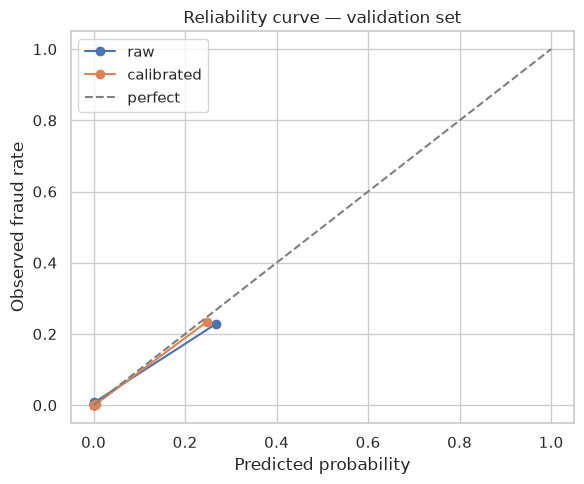

In [35]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

calibrated_v2 = CalibratedClassifierCV(make_models()["Gradient Boosting"], method="isotonic", cv=5).fit(X2_train, y_train)
raw_val = model_v2.predict_proba(X2_val)[:, 1]
cal_val = calibrated_v2.predict_proba(X2_val)[:, 1]

display(pd.DataFrame({
    "mean_predicted_risk": [raw_val.mean(), cal_val.mean()],
    "actual_fraud_rate": [y_val.mean()] * 2,
    "brier_score": [brier_score_loss(y_val, raw_val), brier_score_loss(y_val, cal_val)],
    "pr_auc": [average_precision_score(y_val, raw_val), average_precision_score(y_val, cal_val)],
}, index=["raw (class-weighted)", "calibrated (isotonic)"]).round(4))

fig, ax = plt.subplots(figsize=(6, 5))
for name, p in [("raw", raw_val), ("calibrated", cal_val)]:
    frac_pos, mean_pred = calibration_curve(y_val, p, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)
ax.plot([0, 1], [0, 1], ls="--", c="grey", label="perfect")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed fraud rate")
ax.set_title("Reliability curve — validation set"); ax.legend(); plt.tight_layout()

In [36]:
COST_RATIOS = [5, 20, 50]          # cost(missed fraudster) / cost(reviewing an honest user) — business assumption
THRESHOLD_GRID = np.linspace(0.005, 0.95, 190)


def expected_cost(y_true, scores, threshold, ratio):
    flagged = scores >= threshold
    return (flagged & (y_true == 0)).sum() + ratio * (~flagged & (y_true == 1)).sum()


def cost_optimal_threshold(y_true, scores, ratio):
    costs = [expected_cost(y_true, scores, t, ratio) for t in THRESHOLD_GRID]
    return THRESHOLD_GRID[int(np.argmin(costs))]


y_val_arr = y_val.to_numpy()
cost_table = {}
for ratio in COST_RATIOS:
    t = cost_optimal_threshold(y_val_arr, cal_val, ratio)
    flagged = cal_val >= t
    cost_table[f"R = {ratio}"] = {
        "theoretical 1/(1+R)": 1 / (1 + ratio), "chosen threshold": t,
        "n_flagged": int(flagged.sum()), "precision": precision_score(y_val_arr, flagged),
        "recall": recall_score(y_val_arr, flagged)}
cost_table = pd.DataFrame(cost_table).T
cost_table.round(3)

,theoretical 1/(1+R),chosen threshold,n_flagged,precision,recall
R = 5,0.167,0.435,59.0,0.831,0.817
R = 20,0.048,0.075,94.0,0.564,0.883
R = 50,0.020,0.015,222.0,0.261,0.967


**Observations**
- The raw model was in fact **already reasonably calibrated** (mean predicted risk 3.4% vs 3.0% actual). Most scores are very close to 0 or 1, so the class weights barely distort the average. Isotonic calibration still improves the Brier score (0.0101 → 0.0089) without changing the ranking (same PR-AUC), so the calibrated model is kept for the cost analysis.
- The cost ratio **R drives the operating point**: R = 5 → 59 alerts at 83% precision; R = 20 → 94 alerts, 88% recall; R = 50 → 222 alerts, 97% recall but only 26% precision.
- The empirical optimum differs from the theoretical 1/(1+R). The cost curve is flat around its minimum and is estimated on only 60 fraudsters, so the exact value is noisy. The right R must come from the business (average fraud loss vs analyst cost); **R = 20** is used below as an illustrative assumption.

### 6.4 Explaining alerts (SHAP) and monitoring drift

**SHAP** values break each prediction into the contribution of every feature. Globally they show how features push the risk up or down; locally they tell an analyst **why a given user was flagged**.

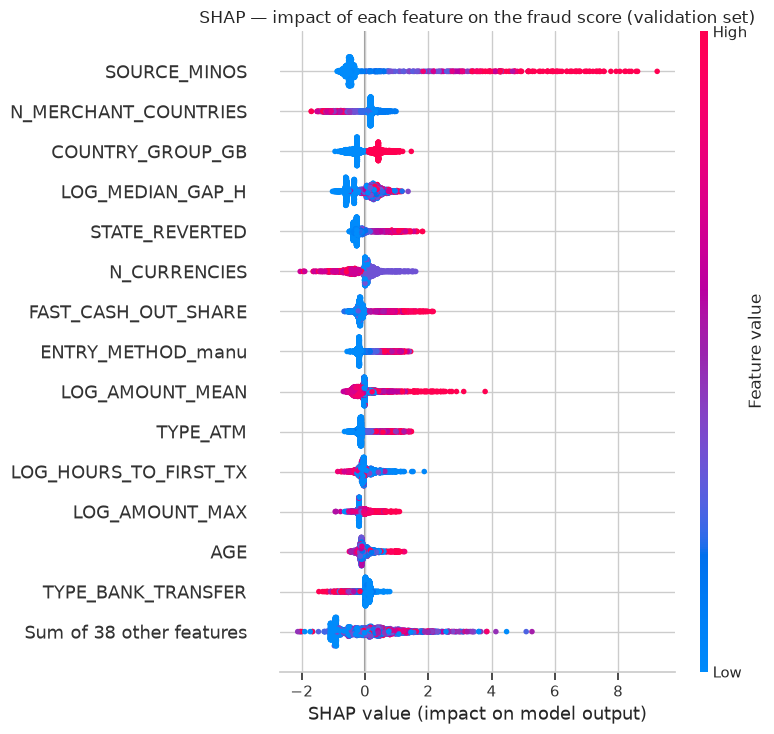

In [37]:
import shap

explainer = shap.TreeExplainer(model_v2)
shap_val = explainer(X2_val)          # contributions in log-odds

shap.plots.beeswarm(shap_val, max_display=15, show=False)
plt.title("SHAP — impact of each feature on the fraud score (validation set)")
plt.tight_layout(); plt.show()

**Observation** — SHAP confirms the permutation-importance ranking and adds the **direction** of each effect:
- a high `SOURCE_MINOS` share, **fast cash-out** after top-ups, high average amounts, ATM use, manual entry, reverted transactions and GB residence push the score **up**;
- **many currencies / merchant countries push it down**. This is the *opposite* of my Step 3 hypothesis ("spending abroad is suspicious"): ordinary customers travel and pay in several currencies, while fraudsters use the account narrowly, as a pass-through for money. The data refuted the hypothesis, and the feature is useful in the other direction.
- A large share of bank transfers also lowers the score *once MINOS is known*: transfers are suspicious mainly when they go through MINOS.

User 0782ced4-7bb6-4420-aff2-ed08290ee47c — score 1.000, actual fraudster: True


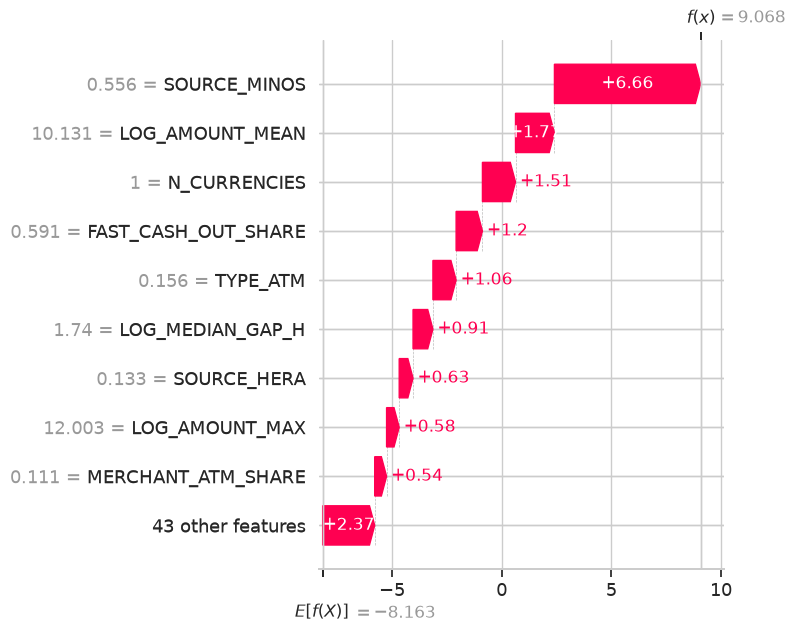

In [38]:
# Local explanation: why was the riskiest validation user flagged?
riskiest = int(np.argmax(raw_val))
print(f"User {X2_val.index[riskiest]} — score {raw_val[riskiest]:.3f}, actual fraudster: {bool(y_val.iloc[riskiest])}")
shap.plots.waterfall(shap_val[riskiest], max_display=10, show=False)
plt.tight_layout(); plt.show()

**Observation** — the waterfall turns a score into a short, readable reason for an analyst, e.g. "flagged because most of its transactions go through MINOS, money is withdrawn quickly after top-ups, and amounts are high". This makes the alerts reviewable and auditable, which a fraud team needs, often for regulatory reasons too.

**Drift monitoring** — a model trained on past users degrades if behaviour changes. The **Population Stability Index (PSI)** compares the distribution of each important feature between older and more recent accounts (rule of thumb: < 0.1 stable, 0.1–0.25 moderate shift, > 0.25 significant shift).

In [39]:
PSI_BINS = 10


def population_stability_index(reference, current, bins=PSI_BINS):
    """PSI between two samples of one feature, using quantile bins of the reference."""
    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:                       # (near) constant feature
        edges = np.unique(np.concatenate([edges, [reference.mean() + 1e-9]]))
    edges[0], edges[-1] = -np.inf, np.inf
    ref_pct = np.histogram(reference, edges)[0] / len(reference) + 1e-6
    cur_pct = np.histogram(current, edges)[0] / len(current) + 1e-6
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))


top_shap = (pd.Series(np.abs(shap_val.values).mean(axis=0), index=FEATURES_V2)
              .sort_values(ascending=False).head(12).index)
created = USER_CREATED.loc[data_v2.index]
older = data_v2[created < created.quantile(TEMPORAL_TRAIN_SHARE)]
newer = data_v2[created >= created.quantile(TEMPORAL_TRAIN_SHARE)]

psi = pd.Series({f: population_stability_index(older[f].to_numpy(), newer[f].to_numpy()) for f in top_shap},
                name="PSI (older vs newest 25% accounts)").sort_values(ascending=False)
psi.round(3).to_frame().assign(status=pd.cut(psi, [-np.inf, 0.1, 0.25, np.inf], labels=["stable", "moderate", "significant"]))

,PSI (older vs newest 25% accounts),status
N_MERCHANT_COUNTRIES,0.608,significant
LOG_AMOUNT_MAX,0.357,significant
LOG_HOURS_TO_FIRST_TX,0.324,significant
N_CURRENCIES,0.282,significant
STATE_REVERTED,0.266,significant
TYPE_ATM,0.225,moderate
LOG_AMOUNT_MEAN,0.225,moderate
LOG_MEDIAN_GAP_H,0.222,moderate
ENTRY_METHOD_manu,0.192,moderate
FAST_CASH_OUT_SHARE,0.165,moderate


**Observations**
- Several important features **shift significantly** between older and newer accounts (number of merchant countries, maximum amount, time to first transaction, number of currencies).
- Part of this is mechanical: newer accounts have had **less time** to transact in many countries / currencies. This is exactly why the temporal PR-AUC (0.77) is lower than the random one, and why fixed-window features (6.2) are more robust.
- `SOURCE_MINOS` and GB residence are **stable**. In production these PSI values would be computed every week or month, with an alert above 0.25 that triggers investigation / retraining.

### 6.5 Final model on the test set

In [40]:
final_scores = calibrated_v2.predict_proba(X2_test)[:, 1]
FINAL_RATIO = 20
final_threshold = cost_table.loc[f"R = {FINAL_RATIO}", "chosen threshold"]
final_pred = final_scores >= final_threshold

pd.DataFrame({
    "Step 5 model (base features, F2 threshold)": {
        "pr_auc": average_precision_score(y_test, test_scores), "roc_auc": roc_auc_score(y_test, test_scores),
        **alert_stats(y_test, test_scores >= THRESHOLD)},
    f"Improved model (+ sequence, calibrated, cost R={FINAL_RATIO})": {
        "pr_auc": average_precision_score(y_test, final_scores), "roc_auc": roc_auc_score(y_test, final_scores),
        **alert_stats(y_test, final_pred)},
}).T.round(3)

,pr_auc,roc_auc,n_flagged,fraud_caught,precision,recall
"Step 5 model (base features, F2 threshold)",0.826,0.989,59.0,45.0,0.763,0.763
"Improved model (+ sequence, calibrated, cost R=20)",0.861,0.992,89.0,52.0,0.584,0.881


**Observation** — on the test set, the improved model ranks fraudsters better (**PR-AUC 0.83 → 0.86**). With the cost-based threshold (R = 20) it **catches 52 of 59 fraudsters (recall 0.88, vs 0.76)**, at the price of more alerts (89 vs 59, precision 0.58). This is the expected trade-off when a missed fraudster is assumed to cost 20× a review. With R = 5 the operating point would be close to the Step 5 one.

## Conclusion

**Approach** — profile + transaction data were aggregated into interpretable user-level features (transaction mix, amounts, timing, geography, cash-in / cash-out, and sequence features), after removing a target leak (`STATE`) and features shaped by the account lock. Three models were compared with stratified cross-validation; **Histogram Gradient Boosting** was selected.

**Results (test set)**

| Model | PR-AUC | Recall | Precision |
|---|---|---|---|
| Step 5 — base features, F2 threshold | 0.83 | 0.76 | 0.76 |
| Step 6 — + sequence features, calibrated, cost threshold (R = 20) | **0.86** | **0.88** | 0.58 |

The more realistic **time-based** evaluation (train on older accounts, test on newer ones) gives PR-AUC ≈ **0.77**. Using only the **first 30 days** of activity still gives ≈ 0.68.

**Key fraud signals** — use of the MINOS channel (bank transfers / top-ups), **fast cash-out after top-ups**, bursts of activity, large amounts, ATM withdrawals, manual card entry, declined / reverted transactions, and a **narrow** usage (few currencies and merchant countries, unlike real customers who travel): overall a *cash-in → cash-out* (money mule) profile.

**Improvements made (Step 6)**
1. Sequence features (top-up → cash-out speed, velocity, declined streaks): CV PR-AUC 0.81 → 0.84, more stable.
2. Early-detection windows (7 / 30 days) and a temporal split: they reveal the optimism of the random split and show how early fraud can be caught.
3. Calibrated probabilities and a cost-based threshold, with the cost ratio exposed as a business parameter.
4. SHAP explanations for each alert, and PSI drift monitoring of the key features.

**Remaining limitations**
- **Few fraudsters** (298, ~60 per evaluation set) → wide uncertainty (± ~0.05 PR-AUC); a larger labelled history would help most.
- **Label bias** — `IS_FRAUDSTER` reflects users that were *caught and locked*; undetected fraudsters are labelled as legitimate. The weight of MINOS could partly reflect how past fraud was detected.
- **Drift** — several key features shift between older and newer accounts; the model would need regular retraining and monitoring.
- The cost ratio R is an **assumption** and must come from real loss / review-cost figures.